# IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score)

# LOAD DATASET

In [3]:
df=pd.read_csv("framingham.csv")

# VIEW DATASET

In [5]:
print("First 5 rows of dataset:")
print(df.head())

First 5 rows of dataset:
   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150.0   95.0  28.58       65.0    103.0   
4             0         0    285.0  130.0   84.0  23.10       85.0     85.0   

   TenYearCHD  
0        

In [6]:
print("\nShape of dataset:")
print(df.shape)


Shape of dataset:
(4240, 16)


In [7]:
print("\nColumn names:")
print(df.columns)


Column names:
Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')


In [8]:
print("\nDataset information:")
print(df.info())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 

In [9]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64


# DROP UNNECESSARY COLUMN

In [10]:
df=df.drop("education",axis=1)

In [11]:
# handle missing values
df=df.dropna()

# UPDATED DATA

In [16]:
print(df.info)
print("\nCHECK MISSING VALUES IN UPDATED DATA ")
print(df.isnull().sum())

<bound method DataFrame.info of       male  age  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0        1   39              0         0.0     0.0                0   
1        0   46              0         0.0     0.0                0   
2        1   48              1        20.0     0.0                0   
3        0   61              1        30.0     0.0                0   
4        0   46              1        23.0     0.0                0   
...    ...  ...            ...         ...     ...              ...   
4233     1   50              1         1.0     0.0                0   
4234     1   51              1        43.0     0.0                0   
4237     0   52              0         0.0     0.0                0   
4238     1   40              0         0.0     0.0                0   
4239     0   39              1        30.0     0.0                0   

      prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  \
0                0         0    195.0  106

# SEPARATE FEATURE AND TARGET

In [17]:
X=df.drop("TenYearCHD",axis=1)
y=df["TenYearCHD"]

# CLASS DISTRIBUTION

Class Distribution:
TenYearCHD
0    3179
1     572
Name: count, dtype: int64


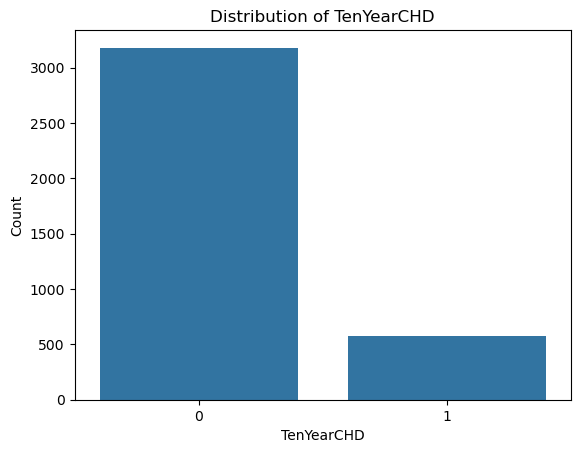

In [19]:
print("Class Distribution:")
print(y.value_counts())
sns.countplot(x=y)
plt.title("Distribution of TenYearCHD")
plt.xlabel("TenYearCHD")
plt.ylabel("Count")
plt.show()

# SPLIT INTO TRAINING AND TESTING DATA

In [21]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.30,random_state=42)

# SCALE THE FEATURES

In [22]:
scaler=StandardScaler()  # using standard deviation
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# TRAIN LOGISTIC REGRESSION MODEL

In [23]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled,y_train)

LogisticRegression(max_iter=1000)

# MAKE PREDICTIONS

In [28]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# EVALUATE MODEL

In [29]:
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:" ,recall)
print("F1-score:",f1)

Accuracy: 0.8339253996447602
Precision: 0.52
Recall: 0.06914893617021277
F1-score: 0.12206572769953052


# CLASSIFICATION REPORT

In [31]:
print("\n Classification Report :")
print(classification_report(y_test,y_pred))


 Classification Report :
              precision    recall  f1-score   support

           0       0.84      0.99      0.91       938
           1       0.52      0.07      0.12       188

    accuracy                           0.83      1126
   macro avg       0.68      0.53      0.52      1126
weighted avg       0.79      0.83      0.78      1126



# CONFUSION MATRIX

In [32]:
cm = confusion_matrix(y_test,y_pred)
print("\n Confusion Matrix")
print(cm)


 Confusion Matrix
[[926  12]
 [175  13]]


# PLOT CONFUSION MATRIX HEATMAP

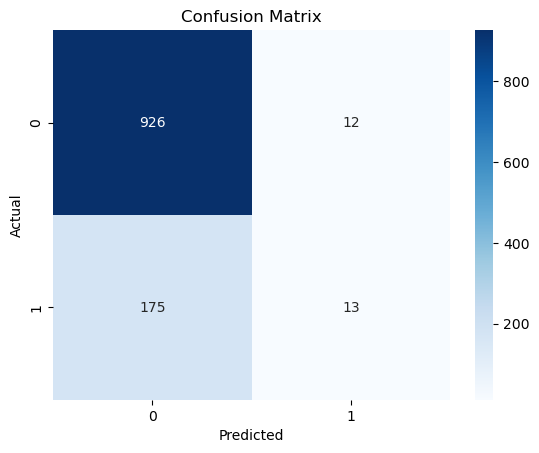

In [33]:
sns.heatmap(cm , annot=True ,fmt ="d" ,cmap ="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC CURVE AND AUC SCORE

ROC-AUC Score:  0.7171097400535318


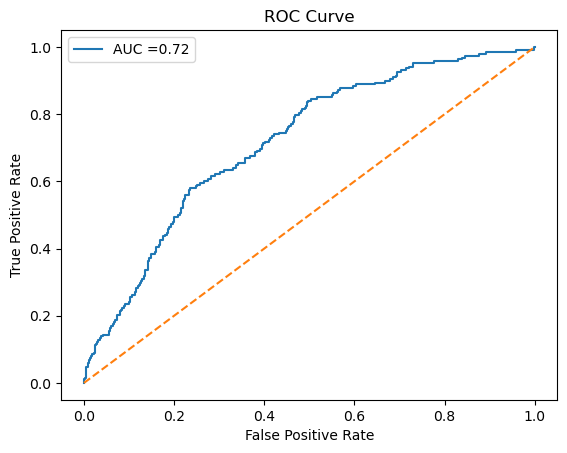

In [34]:
fpr,tpr,thresholds = roc_curve(y_test,y_prob)
auc_score = roc_auc_score(y_test,y_prob)
print("ROC-AUC Score: ",auc_score)

plt.plot(fpr,tpr,label =f"AUC ={auc_score:.2f}")
plt.plot([0,1],[0,1],linestyle ="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# PREDICT FOR NEW PATIENT DATA

In [40]:
new_patient = pd.DataFrame([{
    "male":1,  #1 means male
    "age": 55,
    "currentSmoker":1, #1 means smoker
    "cigsPerDay":15, # cigarettes per day
    "BPMeds": 0, #blood pressure medicine
    "prevalentStroke": 0, #previous stroke
    "prevalentHyp": 1, #hypertension
    "diabetes": 0, #diabetic or not
    "totChol":240, #cholestrol
    "sysBP":150, #systolic BP
    "diaBP":95, #diastolic BP
    "BMI": 28.0, #Body mass index
    "heartRate": 82, #pulse rate
    "glucose": 95 #blood sugar
}])

# SCALE NEW PATIENT DATA

In [41]:
new_patient_scaled = scaler.transform(new_patient)    # using the same scaler fitted on training data

# PREDICT NEW PATIENT CLASS AND PROBABILITY

In [44]:
prediction = model.predict(new_patient_scaled)
probability = model.predict_proba(new_patient_scaled)
print(prediction)
print(probability)

[0]
[[0.67391836 0.32608164]]


# PRINT FINAL NEW PATIENT RESULT

In [46]:
print("Predicted Class:",prediction[0])
print("Probability of No Heart Disease:", probability[0][0])
print("Probability of Heart Disease:" ,probability[0][1])

if prediction[0]==1:
    print("The patient is at risk of heart diases in 10 years.")
else:
    print("The patient is not at risk of heart diases in 10 years.")
    

Predicted Class: 0
Probability of No Heart Disease: 0.6739183617235438
Probability of Heart Disease: 0.32608163827645614
The patient is not at risk of heart diases in 10 years.
